# `PHI_2.h5` potential using the legacy GC2D loader

This notebook visualizes `data/potential/V1/PHI_2.h5` with the same data interpretation as `extract_potential` in the legacy `gc2d_classes.py` project. It treats the first zero-frequency field as the mean potential, retains positive-frequency fields as fluctuations, sorts them by amplitude, normalizes the retained potential by $2\pi f_0 B$, and reconstructs

$$
\Phi(R,Z,t)=\Phi_0(R,Z)+2\sum_j\operatorname{Re}\left[\widetilde\Phi_j(R,Z)e^{i f_jt}\right].
$$

The source HDF5 file does not store units. The notebook therefore preserves the names and numerical values without assigning physical units.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import h5py
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from scipy import ndimage
from scipy.interpolate import RectBivariateSpline

plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

## Reproducible configuration

`B=1.5`, `indx=[0, 1]`, and a $128\times128$ interpolation define the potential used below. Index `0` selects the mean field and index `1` selects the largest retained fluctuation after sorting.

In [2]:
potential_path = Path("../../data/potential/V1/PHI_2.h5")

B = 1.5
indx = (0, 1)
nx = 128
ny = 128
denoising = False
denoising_sigma = 1.0
snapshot_time = 0.0

animation_enabled = True
animation_frame_count = 31
animation_interval_ms = 100

if not potential_path.is_file():
    raise FileNotFoundError(f"Potential file not found: {potential_path.resolve()}")
if B == 0:
    raise ValueError("`B` must be non-zero because it enters the legacy normalization.")

## Loader compatible with `gc2d_classes.extract_potential`

The legacy module cannot be imported directly in this environment because its unrelated trajectory class requires `pyhamsys`. The implementation below reproduces the loader's selection, sorting, normalization, denoising, interpolation, and time convention. It reads only the fields that survive the frequency filtering instead of materializing the entire compressed cube, which does not change the returned potential.

In [3]:
@dataclass(frozen=True)
class GC2DLoadedPotential:
    """Potential arrays selected and normalized like the legacy GC2D loader."""

    x: np.ndarray
    y: np.ndarray
    mean_value: np.ndarray | None
    fluctuations: np.ndarray | None
    freqs: np.ndarray
    source_field_indices: np.ndarray
    normalization_factor: float
    attributes: dict[str, np.ndarray]

    def evaluate(self, time):
        """Return Phi(x, y, time) with the legacy positive-frequency convention."""
        if self.mean_value is not None:
            result = self.mean_value.copy()
        elif self.fluctuations is not None and len(self.fluctuations):
            result = np.zeros_like(self.fluctuations[0].real)
        else:
            raise ValueError("The selected potential contains no field.")
        if self.fluctuations is not None:
            for fluctuation, frequency in zip(self.fluctuations, self.freqs):
                result += 2.0 * np.real(fluctuation * np.exp(1j * frequency * time))
        return result

    def dynamic_part(self, time):
        """Return only the time-dependent contribution to the potential."""
        result = np.zeros((self.x.size, self.y.size), dtype=float)
        if self.fluctuations is not None:
            for fluctuation, frequency in zip(self.fluctuations, self.freqs):
                result += 2.0 * np.real(fluctuation * np.exp(1j * frequency * time))
        return result


def _resample_fields(x, y, mean_value, fluctuations, *, nx, ny, order=3):
    """Apply the same rectangular-spline interpolation used by Potential."""
    if nx is None and ny is None:
        return x, y, mean_value, fluctuations
    if nx is None or ny is None:
        raise ValueError("`nx` and `ny` must either both be set or both be None.")
    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)

    # Potential.interpolate extends a non-periodic grid by k+1 zero-valued cells.
    left_padding = order + 1
    right_padding = order + 1
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    extended_x = np.pad(
        x,
        (left_padding, right_padding),
        mode="linear_ramp",
        end_values=(x.min() - left_padding * dx, x.max() + right_padding * dx),
    )
    extended_y = np.pad(
        y,
        (left_padding, right_padding),
        mode="linear_ramp",
        end_values=(y.min() - left_padding * dy, y.max() + right_padding * dy),
    )

    def interpolate_component(values):
        extended_values = np.pad(
            values,
            ((left_padding, right_padding), (left_padding, right_padding)),
            mode="constant",
            constant_values=0,
        )
        return RectBivariateSpline(
            extended_x, extended_y, extended_values, kx=order, ky=order
        )(xi, yi)

    if mean_value is not None:
        mean_value = interpolate_component(mean_value)
    if fluctuations is not None:
        interpolated = []
        for field in fluctuations:
            real_part = interpolate_component(field.real)
            imag_part = interpolate_component(field.imag)
            interpolated.append(real_part + 1j * imag_part)
        fluctuations = np.asarray(interpolated)
    return xi, yi, mean_value, fluctuations


def extract_potential_like_gc2d(
    filename, B=1.0, indx=None, nx=None, ny=None, denoising=False, sigma=1.0
):
    """Load an HDF5 potential with `gc2d_classes.extract_potential` semantics."""
    with h5py.File(filename, "r") as h5:
        x = np.asarray(h5["Rcells"][()])
        y = np.asarray(h5["Zcells"][()])
        all_freqs = np.atleast_1d(h5["freqs"][()])
        fields = h5["fields"]
        attributes = {name: np.asarray(value) for name, value in h5.attrs.items()}

        expected_shape = (len(all_freqs), len(y), len(x))
        if fields.shape != expected_shape:
            raise ValueError(
                f"Shape of `fields` in {filename} is {fields.shape}, "
                f"but expected {expected_shape}."
            )

        zero_mask = np.isclose(all_freqs, 0, atol=1e-5)
        zero_indices = np.flatnonzero(zero_mask)
        mean_value = fields[zero_indices[0]].real if zero_indices.size else None

        # The legacy loader removes zero and negative frequencies before sorting.
        retained_indices = np.flatnonzero((~zero_mask) & (all_freqs >= 0))
        retained_freqs = all_freqs[retained_indices]
        if retained_indices.size:
            retained_fields = np.asarray([fields[index] for index in retained_indices])
            amplitudes = np.ptp(retained_fields, axis=(1, 2))
            sort_indices = np.argsort(amplitudes)[::-1]
            retained_freqs = retained_freqs[sort_indices]
            retained_fields = retained_fields[sort_indices]
            retained_indices = retained_indices[sort_indices]
            normalization_factor = float(2.0 * np.pi * retained_freqs[0] * B)
            retained_fields = retained_fields / normalization_factor
            if mean_value is not None:
                mean_value = mean_value / normalization_factor
        else:
            retained_fields = np.empty((0, len(y), len(x)), dtype=np.complex128)
            normalization_factor = 1.0

    if indx is None:
        selected = np.arange(len(retained_freqs) + 1)
    else:
        selected = np.atleast_1d(indx).astype(int)
        if selected.size == 0 or selected.min() < 0 or selected.max() > len(retained_freqs):
            raise ValueError(f"Indices must be in range [0, {len(retained_freqs)}].")

    mean_value = mean_value if 0 in selected else None
    fluctuation_selection = selected[selected != 0] - 1
    selected_freqs = retained_freqs[fluctuation_selection]
    selected_fields = retained_fields[fluctuation_selection]
    selected_source_indices = retained_indices[fluctuation_selection]
    fluctuations = selected_fields.astype(np.complex128) if selected_freqs.size else None

    if denoising and fluctuations is not None:
        fluctuations = np.asarray(
            [
                ndimage.gaussian_filter(field.real, sigma=sigma)
                + 1j * ndimage.gaussian_filter(field.imag, sigma=sigma)
                for field in fluctuations
            ]
        )
    if denoising and mean_value is not None:
        mean_value = ndimage.gaussian_filter(mean_value, sigma=sigma)

    x, y, mean_value, fluctuations = _resample_fields(
        x, y, mean_value, fluctuations, nx=nx, ny=ny
    )
    return GC2DLoadedPotential(
        x=x,
        y=y,
        mean_value=mean_value,
        fluctuations=fluctuations,
        freqs=selected_freqs,
        source_field_indices=selected_source_indices,
        normalization_factor=normalization_factor,
        attributes=attributes,
    )

## Load and inspect the selected potential

The literal HDF5 structure is reported first, followed by the subset and scaling actually returned by the legacy-compatible loader.

In [4]:
with h5py.File(potential_path, "r") as h5:
    raw_frequencies = h5["freqs"][...]
    raw_field_shape = h5["fields"].shape
    raw_field_dtype = h5["fields"].dtype
    zero_frequency_count = int(np.count_nonzero(np.isclose(raw_frequencies, 0, atol=1e-5)))

potential = extract_potential_like_gc2d(
    potential_path,
    B=B,
    indx=indx,
    nx=nx,
    ny=ny,
    denoising=denoising,
    sigma=denoising_sigma,
)

print(f"File: {potential_path.resolve()}")
print(f"Raw fields: shape={raw_field_shape}, dtype={raw_field_dtype}")
print(f"Raw frequencies: {zero_frequency_count} zero and {raw_frequencies.size - zero_frequency_count} non-zero")
print(f"Selected source field indices: {potential.source_field_indices.tolist()}")
print(f"Selected frequencies: {potential.freqs.tolist()}")
print(f"Legacy normalization 2*pi*f0*B: {potential.normalization_factor:.12g}")
print(f"Output grid: {potential.x.size} x {potential.y.size}")
print("File attributes:", {name: value.tolist() for name, value in potential.attributes.items()})
if potential.mean_value is not None:
    print(
        f"Normalized mean range: [{potential.mean_value.min():.6g}, "
        f"{potential.mean_value.max():.6g}]"
    )
if potential.fluctuations is not None:
    for field_index, (source_index, frequency, field) in enumerate(
        zip(potential.source_field_indices, potential.freqs, potential.fluctuations)
    ):
        print(
            f"Fluctuation {field_index}: source fields[{source_index}], f={frequency:.12g}, "
            f"max |field|={np.abs(field).max():.6g}"
        )

File: /home/juan/Proyectos/GC2D_intranet/data/potential/V1/PHI_2.h5
Raw fields: shape=(602, 256, 256), dtype=complex128
Raw frequencies: 601 zero and 1 non-zero
Selected source field indices: [15]
Selected frequencies: [2404.106675108847]
Legacy normalization 2*pi*f0*B: 22658.1716069
Output grid: 128 x 128
File attributes: {'rho0': [0.00022764301909172863], 'tau0': [1.0364268828239422e-08]}
Normalized mean range: [1.05183e-05, 0.000489247]
Fluctuation 0: source fields[15], f=2404.10667511, max |field|=1.70447e-05


## Mean and selected fluctuation

These panels mirror the quantities displayed by the legacy `Potential.plot_potential`: the normalized zero-frequency field and the real and imaginary parts of each selected fluctuation.

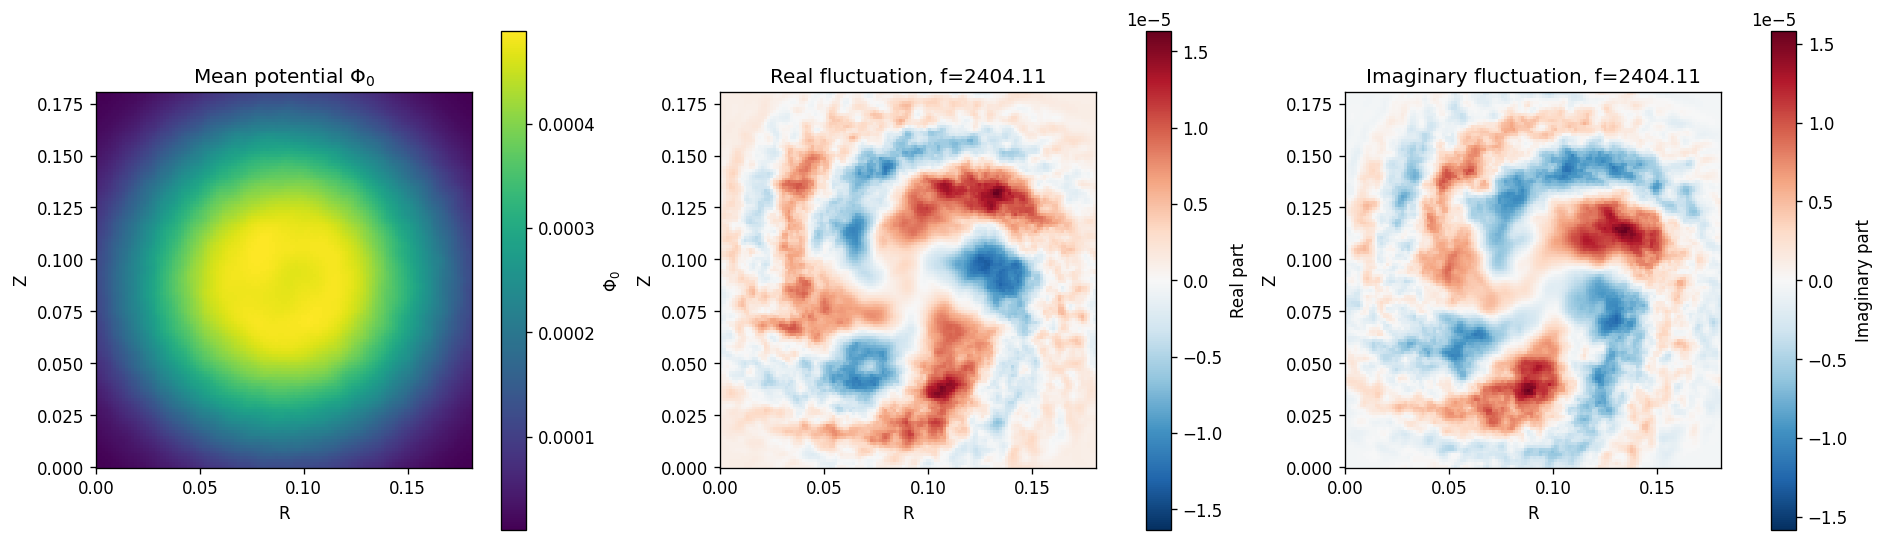

In [5]:
def draw_field(axis, values, *, title, cmap="viridis", symmetric=False):
    """Draw an array stored in (R, Z) order."""
    kwargs = {}
    if symmetric:
        limit = max(float(np.max(np.abs(values))), np.finfo(float).eps)
        kwargs = {"vmin": -limit, "vmax": limit}
    image = axis.pcolormesh(
        potential.x, potential.y, values.T, shading="auto", cmap=cmap, **kwargs
    )
    axis.set(xlabel="R", ylabel="Z", title=title)
    axis.set_aspect("equal")
    return image

panel_count = (1 if potential.mean_value is not None else 0) + (
    2 * len(potential.fluctuations) if potential.fluctuations is not None else 0
)
figure, axes = plt.subplots(1, panel_count, figsize=(5.2 * panel_count, 4.5), constrained_layout=True)
axes = np.atleast_1d(axes)
panel = 0
if potential.mean_value is not None:
    image = draw_field(axes[panel], potential.mean_value, title=r"Mean potential $\Phi_0$")
    figure.colorbar(image, ax=axes[panel], label=r"$\Phi_0$")
    panel += 1
if potential.fluctuations is not None:
    for fluctuation, frequency in zip(potential.fluctuations, potential.freqs):
        real_image = draw_field(
            axes[panel], fluctuation.real, title=fr"Real fluctuation, f={frequency:.6g}", cmap="RdBu_r", symmetric=True
        )
        figure.colorbar(real_image, ax=axes[panel], label="Real part")
        panel += 1
        imag_image = draw_field(
            axes[panel], fluctuation.imag, title=fr"Imaginary fluctuation, f={frequency:.6g}", cmap="RdBu_r", symmetric=True
        )
        figure.colorbar(imag_image, ax=axes[panel], label="Imaginary part")
        panel += 1
plt.show()

## Fluctuation amplitude and phase

The real-space oscillation amplitude is $2|\widetilde\Phi|$. The phase map determines the local phase shift of the oscillation.

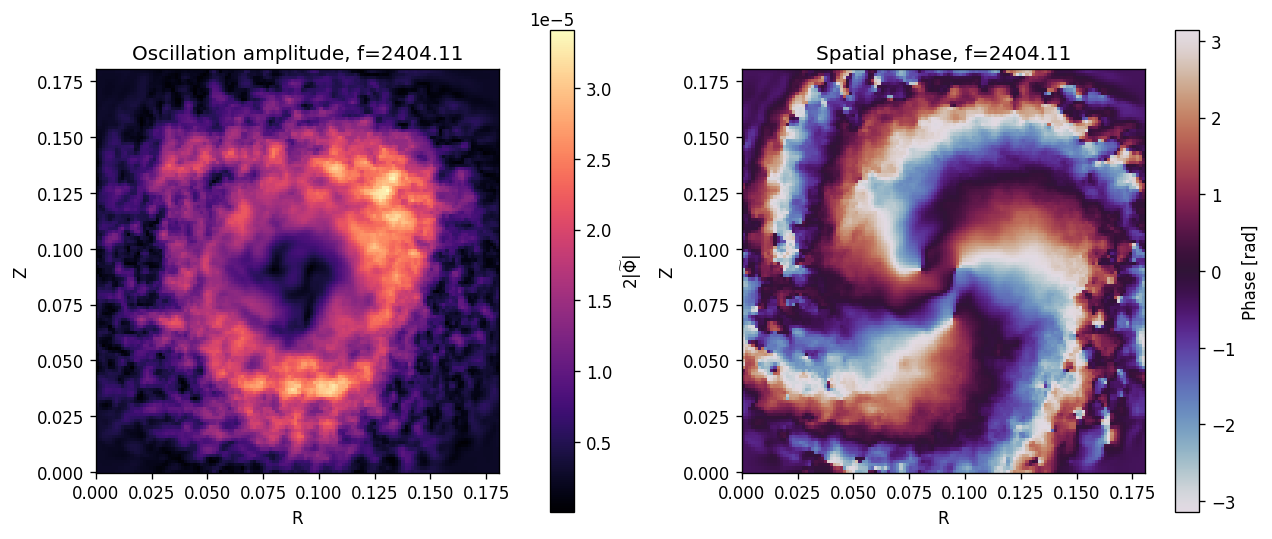

In [6]:
if potential.fluctuations is not None:
    for fluctuation, frequency in zip(potential.fluctuations, potential.freqs):
        figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.5), constrained_layout=True)
        amplitude_image = draw_field(
            axes[0], 2.0 * np.abs(fluctuation), title=fr"Oscillation amplitude, f={frequency:.6g}", cmap="magma"
        )
        phase_image = draw_field(
            axes[1], np.angle(fluctuation), title=fr"Spatial phase, f={frequency:.6g}", cmap="twilight"
        )
        figure.colorbar(amplitude_image, ax=axes[0], label=r"$2|\widetilde\Phi|$")
        figure.colorbar(phase_image, ax=axes[1], label="Phase [rad]")
        plt.show()
else:
    print("No fluctuation was selected.")

## Potential over one temporal period

For the selected single fluctuation, one period is $T=2\pi/|f|$ under the exact $e^{ift}$ convention used in `gc2d_classes.py`. All panels share one color scale.

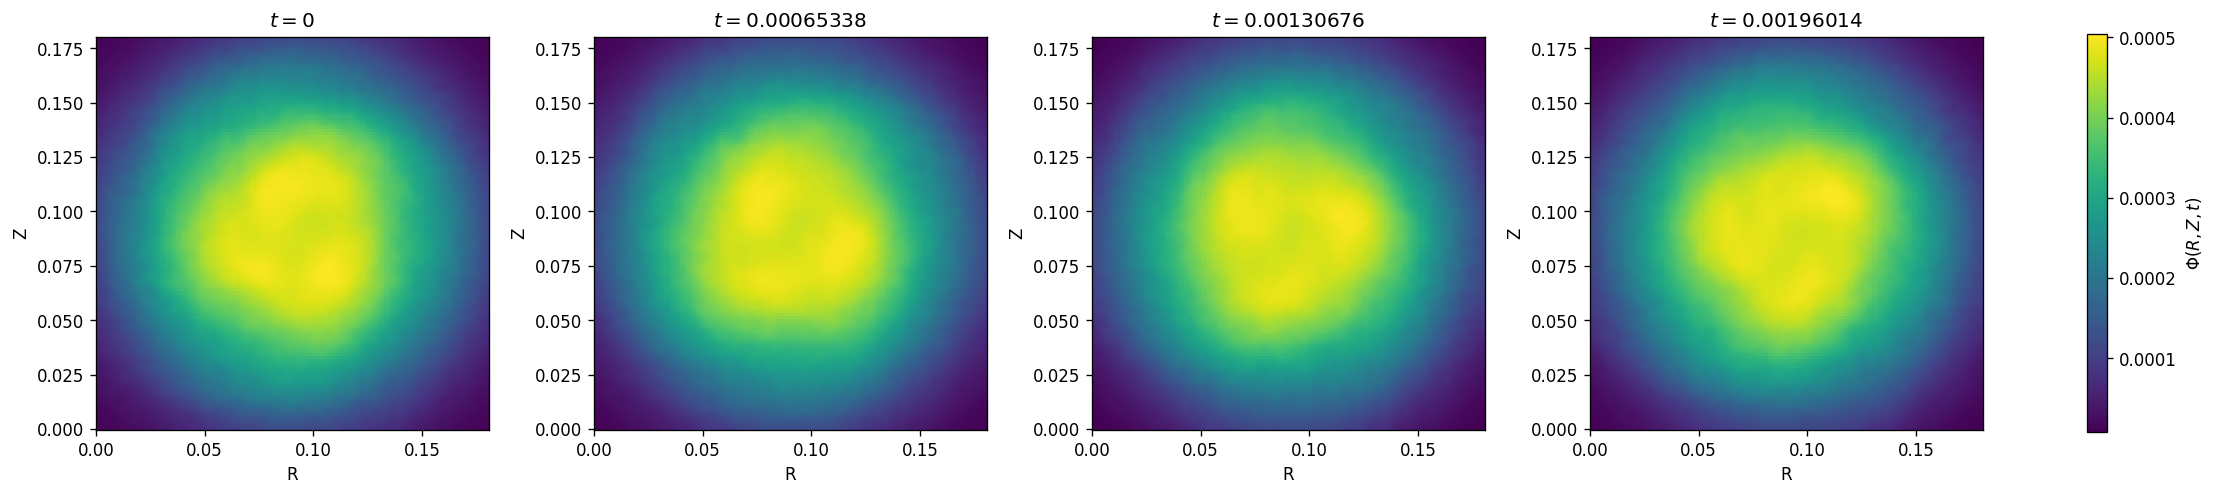

Displayed temporal period: 0.00261352184253


In [7]:
if potential.freqs.size:
    base_frequency = float(np.min(np.abs(potential.freqs)))
    temporal_period = 2.0 * np.pi / base_frequency
    phase_times = temporal_period * np.array([0.0, 0.25, 0.5, 0.75])
else:
    temporal_period = np.nan
    phase_times = np.array([snapshot_time])

snapshots = [potential.evaluate(time) for time in phase_times]
shared_min = min(float(values.min()) for values in snapshots)
shared_max = max(float(values.max()) for values in snapshots)
figure, axes = plt.subplots(1, len(snapshots), figsize=(4.6 * len(snapshots), 4.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for axis, time, values in zip(axes, phase_times, snapshots):
    image = axis.pcolormesh(
        potential.x, potential.y, values.T, shading="auto", cmap="viridis", vmin=shared_min, vmax=shared_max
    )
    axis.set(xlabel="R", ylabel="Z", title=fr"$t={time:.6g}$")
    axis.set_aspect("equal")
figure.colorbar(image, ax=axes, label=r"$\Phi(R,Z,t)$", shrink=0.85)
plt.show()
print(f"Displayed temporal period: {temporal_period:.12g}")

## Time trace at maximum fluctuation amplitude

This trace isolates the temporal interpretation from the spatial maps by evaluating the potential at the grid point where the selected fluctuation is strongest.

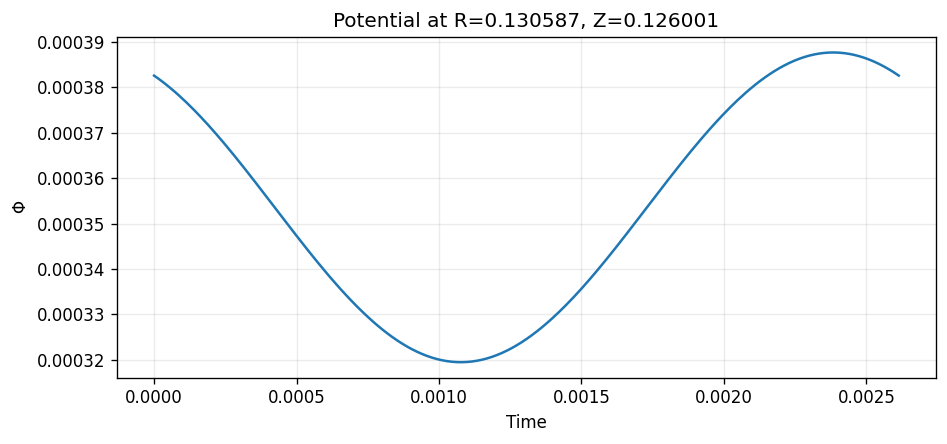

In [8]:
if potential.fluctuations is not None and potential.freqs.size:
    peak_index = np.unravel_index(
        np.argmax(np.abs(potential.fluctuations[0])), potential.fluctuations[0].shape
    )
    trace_times = np.linspace(0.0, temporal_period, 301)
    trace_values = np.asarray(
        [potential.evaluate(time)[peak_index] for time in trace_times]
    )
    figure, axis = plt.subplots(figsize=(8, 3.8))
    axis.plot(trace_times, trace_values, color="tab:blue")
    axis.set(
        xlabel="Time",
        ylabel=r"$\Phi$",
        title=fr"Potential at R={potential.x[peak_index[0]]:.6g}, Z={potential.y[peak_index[1]]:.6g}",
    )
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    plt.show()
else:
    print("A temporal trace requires at least one selected fluctuation.")

## Constant, variable, and total potential animation

The three synchronized panels show the constant component $\Phi_0$, the variable component $\Phi_{\mathrm{var}}(t)=2\operatorname{Re}(\widetilde\Phi e^{ift})$, and their sum. Every color scale remains fixed throughout the animation, and the temporal phase follows the legacy GC2D Hamiltonian.

In [9]:
if animation_enabled and potential.freqs.size:
    animation_times = np.linspace(0.0, temporal_period, animation_frame_count)
    constant_values = (
        potential.mean_value
        if potential.mean_value is not None
        else np.zeros((potential.x.size, potential.y.size), dtype=float)
    )
    amplitude_bound = sum(2.0 * np.abs(field) for field in potential.fluctuations)
    variable_limit = max(float(np.max(amplitude_bound)), np.finfo(float).eps)
    total_min = float(np.min(constant_values - amplitude_bound))
    total_max = float(np.max(constant_values + amplitude_bound))

    initial_variable = potential.dynamic_part(animation_times[0])
    initial_total = constant_values + initial_variable
    figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)
    constant_image = axes[0].pcolormesh(
        potential.x, potential.y, constant_values.T, shading="auto", cmap="viridis"
    )
    variable_image = axes[1].pcolormesh(
        potential.x,
        potential.y,
        initial_variable.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=-variable_limit,
        vmax=variable_limit,
    )
    total_image = axes[2].pcolormesh(
        potential.x,
        potential.y,
        initial_total.T,
        shading="auto",
        cmap="viridis",
        vmin=total_min,
        vmax=total_max,
    )
    panel_titles = (
        r"Constant $\Phi_0$",
        r"Variable $\Phi_{\mathrm{var}}(t)$",
        r"Sum $\Phi_0+\Phi_{\mathrm{var}}(t)$",
    )
    for axis, title in zip(axes, panel_titles):
        axis.set(xlabel="R", ylabel="Z", title=title)
        axis.set_aspect("equal")
    figure.colorbar(constant_image, ax=axes[0], label=r"$\Phi_0$")
    figure.colorbar(variable_image, ax=axes[1], label=r"$\Phi_{\mathrm{var}}$")
    figure.colorbar(total_image, ax=axes[2], label=r"$\Phi$")
    time_title = figure.suptitle(fr"Legacy GC2D potential, $t={animation_times[0]:.6g}$")

    def update_animation(time):
        """Update the variable and total panels at one time."""
        variable_values = potential.dynamic_part(time)
        variable_image.set_array(variable_values.T.ravel())
        total_image.set_array((constant_values + variable_values).T.ravel())
        time_title.set_text(fr"Legacy GC2D potential, $t={time:.6g}$")
        return constant_image, variable_image, total_image, time_title

    animation = FuncAnimation(
        figure,
        update_animation,
        frames=animation_times,
        interval=animation_interval_ms,
        blit=False,
        repeat=True,
    )
    plt.close(figure)
    display(HTML(animation.to_jshtml()))
elif animation_enabled:
    print("No selected fluctuation is available for animation.")
else:
    print("Animation disabled. Set `animation_enabled = True` and rerun from the configuration cell.")

## Interpretation notes

- With this file and `indx=[0, 1]`, the loader selects `fields[0]` as the mean and `fields[15]` as the only fluctuation.
- The other zero-frequency planes are discarded exactly as in `gc2d_classes.extract_potential`.
- `rho0` and `tau0` are reported but are not used by the legacy loader.
- The factor $2\pi f_0 B$ and the phase $e^{if_jt}$ deliberately follow the source code, even though the HDF5 file itself does not document the frequency units.